# Short-time Fourier transform PSD

## tl;dr

- EEG is resampled to 125 Hz and analyzed with a periodic 2 s Hann window.
- STFT slices advance by 32 samples (0.256 s); padded border slices are excluded.
- `mfft=250` gives a native 0.5 Hz grid with one-sided PSD scaling; density is power-preservingly rebinned to the exact 2-40 Hz, 1 Hz output grid.
- Synthetic tests validate burst timing, peak frequency, and integrated PSD before one canonical `exec` and `patt` block are inspected.

## Context and scope

This notebook validates spectral preprocessing checkpoint 7. It demonstrates the STFT transform and artifact contract; it does not compare recording families statistically and does not define an ML split.

STFT and FFT values are power spectral density, whereas Morlet and Superlet values are wavelet power. Their absolute amplitudes must not be compared directly. Any logarithmic conversion below is display-only and is not written to cached features.

In [1]:
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-stft")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessors import (
    STFTConfig,
    build_short_time_fft,
    compute_stft_psd,
    load_preprocessing_config,
    minimum_unpadded_samples,
)
from utils.datasets import STFTDataset


config = load_preprocessing_config("stft")
assert isinstance(config, STFTConfig)
transform = build_short_time_fft(config)

pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "analysis_sfreq_hz": config.analysis_sfreq,
        "window": config.window,
        "window_samples": transform.m_num,
        "window_seconds": transform.m_num / config.analysis_sfreq,
        "hop_samples": transform.hop,
        "time_step_seconds": transform.delta_t,
        "mfft": transform.mfft,
        "native_frequency_step_hz": transform.delta_f,
        "output_frequency_range_hz": f"{config.f_min:g}-{config.f_max:g}",
        "output_frequency_step_hz": config.frequency_step,
        "fft_mode": transform.fft_mode,
        "scaling": transform.scaling,
        "minimum_unpadded_samples": minimum_unpadded_samples(transform),
        "output_dtype": config.dtype,
    },
    name="STFT configuration",
)

project_root                 /home/slauva/Projects/master-thesis-2024-2026/...
analysis_sfreq_hz                                                        125.0
window                                                                    hann
window_samples                                                             250
window_seconds                                                             2.0
hop_samples                                                                 32
time_step_seconds                                                        0.256
mfft                                                                       250
native_frequency_step_hz                                                   0.5
output_frequency_range_hz                                                 2-40
output_frequency_step_hz                                                   1.0
fft_mode                                                            onesided2X
scaling                                             

## Synthetic validation

Two Hann-tapered bursts test time-frequency localization after 1000-to-125 Hz resampling. A separate stationary 10 Hz sine tests the PSD contract: integrating each output spectrum over frequency must recover the signal mean square. Only slices whose full 2 s window lies inside the signal are retained.

burst_output_shape                      (1, 39, 32)
burst_runtime_seconds                      0.002057
first_valid_time_s                            1.024
last_valid_time_s                              8.96
stationary_expected_mean_square                 2.0
stationary_max_abs_integration_error            0.0
finite                                         True
non_negative                                   True
Name: Synthetic validation, dtype: object

,expected_frequency_hz,expected_interval_s,peak_time_s,peak_frequency_at_center_hz
0,10.0,2-4,3.072,10.0
1,25.0,6-8,6.912,25.0


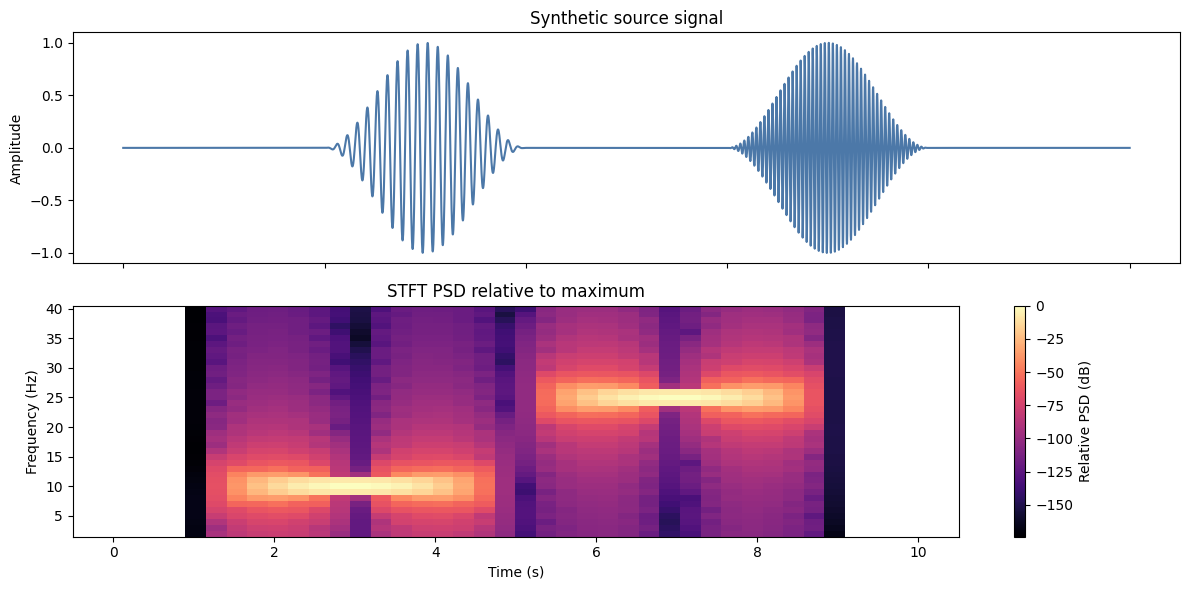

In [2]:
def burst(
    time: np.ndarray,
    *,
    frequency: float,
    start: float,
    stop: float,
) -> np.ndarray:
    mask = (time >= start) & (time < stop)
    envelope = np.zeros_like(time)
    envelope[mask] = np.hanning(mask.sum())
    return envelope * np.sin(2.0 * np.pi * frequency * time)


source_sfreq = 1_000.0
source_time = np.arange(10_000, dtype=np.float64) / source_sfreq
synthetic_eeg = (
    burst(source_time, frequency=10.0, start=2.0, stop=4.0)
    + burst(source_time, frequency=25.0, start=6.0, stop=8.0)
)[np.newaxis, :]

started = perf_counter()
synthetic_result = compute_stft_psd(
    synthetic_eeg,
    source_sfreq=source_sfreq,
    config=config,
)
synthetic_seconds = perf_counter() - started

localization_rows = []
for frequency, start, stop in ((10.0, 2.0, 4.0), (25.0, 6.0, 8.0)):
    frequency_index = int(np.searchsorted(synthetic_result.frequencies, frequency))
    peak_time = float(
        synthetic_result.times[
            np.argmax(synthetic_result.eeg_power[0, frequency_index])
        ]
    )
    burst_center = (start + stop) / 2.0
    time_index = int(np.argmin(np.abs(synthetic_result.times - burst_center)))
    peak_frequency = float(
        synthetic_result.frequencies[
            np.argmax(synthetic_result.eeg_power[0, :, time_index])
        ]
    )
    assert start <= peak_time <= stop
    assert peak_frequency == frequency
    localization_rows.append(
        {
            "expected_frequency_hz": frequency,
            "expected_interval_s": f"{start:g}-{stop:g}",
            "peak_time_s": peak_time,
            "peak_frequency_at_center_hz": peak_frequency,
        }
    )

amplitude = 2.0
stationary_time = np.arange(1_000, dtype=np.float64) / config.analysis_sfreq
stationary_eeg = (
    amplitude * np.sin(2.0 * np.pi * 10.0 * stationary_time)
)[np.newaxis, :]
stationary_result = compute_stft_psd(
    stationary_eeg,
    source_sfreq=config.analysis_sfreq,
    config=config,
)
integrated_power = stationary_result.eeg_power[0].sum(axis=0) * config.frequency_step
expected_mean_square = amplitude**2 / 2.0
assert synthetic_result.eeg_power.shape == (1, 39, 32)
assert np.allclose(np.diff(synthetic_result.times), 0.256)
assert np.allclose(integrated_power, expected_mean_square, rtol=1e-5, atol=1e-6)

validation = pd.Series(
    {
        "burst_output_shape": synthetic_result.eeg_power.shape,
        "burst_runtime_seconds": synthetic_seconds,
        "first_valid_time_s": float(synthetic_result.times[0]),
        "last_valid_time_s": float(synthetic_result.times[-1]),
        "stationary_expected_mean_square": expected_mean_square,
        "stationary_max_abs_integration_error": float(
            np.max(np.abs(integrated_power - expected_mean_square))
        ),
        "finite": bool(np.isfinite(synthetic_result.eeg_power).all()),
        "non_negative": bool(np.all(synthetic_result.eeg_power >= 0)),
    },
    name="Synthetic validation",
)
display(validation)
display(pd.DataFrame(localization_rows))

relative_db = 10.0 * np.log10(
    np.maximum(synthetic_result.eeg_power[0], np.finfo(np.float32).tiny)
)
relative_db -= relative_db.max()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(source_time, synthetic_eeg[0], color="#4C78A8")
axes[0].set(ylabel="Amplitude", title="Synthetic source signal")
mesh = axes[1].pcolormesh(
    synthetic_result.times,
    synthetic_result.frequencies,
    relative_db,
    shading="auto",
    cmap="magma",
)
axes[1].set(xlabel="Time (s)", ylabel="Frequency (Hz)", title="STFT PSD relative to maximum")
fig.colorbar(mesh, ax=axes[1], label="Relative PSD (dB)")
fig.tight_layout()

## Canonical real blocks and artifact cache

The first stable-index block from each recording family is used only for I/O and transform-contract validation. Original EOG remains in the source dataset and is neither transformed nor duplicated in the spectral artifact.

,key,eeg_power_shape,eog_shape,first_valid_time_s,last_valid_time_s,first_access_seconds,cached_access_seconds,artifact_kib
family,,,,,,,,
exec,"(1, 1, 1)","(63, 39, 55)","(5, 16001)",1.024,14.848000,0.041130,0.001689,530.766602
patt,"(1, 1, 1)","(63, 39, 94)","(5, 26001)",1.024,24.832001,0.034591,0.002103,905.231445


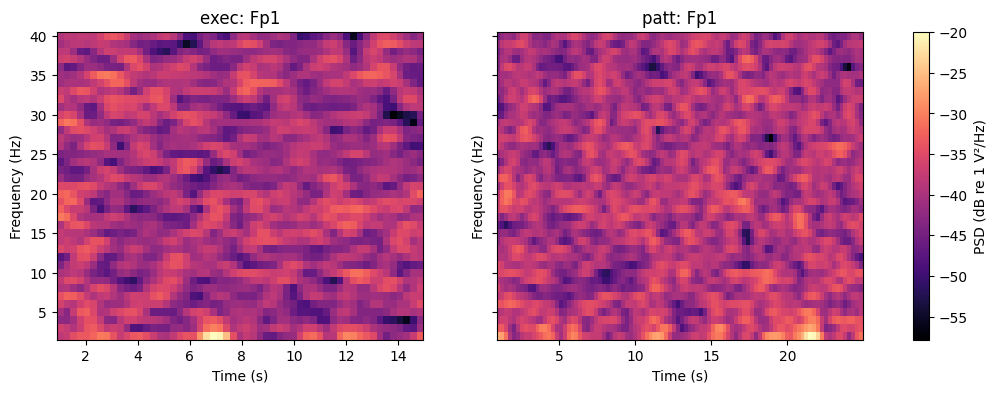

In [3]:
dataset_specs = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "dataset_step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "dataset_step_type": "patt",
    },
}

rows = []
real_samples = {}
for family, spec in dataset_specs.items():
    dataset = STFTDataset(**spec)
    started = perf_counter()
    sample = dataset[0]
    first_access_seconds = perf_counter() - started
    started = perf_counter()
    cached = dataset[0]
    cached_access_seconds = perf_counter() - started
    entry_dir = dataset.get_cache_entry_path(0)
    cache_bytes = sum(path.stat().st_size for path in entry_dir.iterdir() if path.is_file())

    assert sample.eeg_power.ndim == 3
    assert sample.eeg_power.shape[:2] == (63, 39)
    assert sample.times is not None
    assert np.allclose(np.diff(sample.times), 0.256)
    assert np.array_equal(sample.frequencies, np.arange(2.0, 41.0, dtype=np.float32))
    assert np.array_equal(cached.eeg_power, sample.eeg_power)
    assert np.array_equal(cached.times, sample.times)
    assert sample.eog.shape[0] == 5

    real_samples[family] = sample
    rows.append(
        {
            "family": family,
            "key": (
                sample.sample.subject_id,
                sample.sample.trial_number,
                sample.sample.block_index,
            ),
            "eeg_power_shape": sample.eeg_power.shape,
            "eog_shape": sample.eog.shape,
            "first_valid_time_s": float(sample.times[0]),
            "last_valid_time_s": float(sample.times[-1]),
            "first_access_seconds": first_access_seconds,
            "cached_access_seconds": cached_access_seconds,
            "artifact_kib": cache_bytes / 1024.0,
        }
    )

real_summary = pd.DataFrame(rows).set_index("family")
display(real_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, (family, sample) in zip(axes, real_samples.items(), strict=True):
    channel_psd = sample.eeg_power[0]
    psd_db = 10.0 * np.log10(np.maximum(channel_psd, np.finfo(np.float32).tiny))
    mesh = axis.pcolormesh(sample.times, sample.frequencies, psd_db, shading="auto", cmap="magma")
    axis.set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title=f"{family}: {sample.eeg_channels[0]}",
    )
fig.colorbar(mesh, ax=axes, label="PSD (dB re 1 V²/Hz)")

## Conclusions

- The periodic 2 s Hann STFT produces one-sided PSD on a native 0.5 Hz grid and advances every 0.256 s.
- Power-preserving overlap rebinning maps native density bins to the exact 2-40 Hz, 1 Hz project grid without the scaling error caused by subsampling frequency bins.
- All retained time slices use windows fully contained in the resampled signal; no padded border slices enter stored features.
- Synthetic bursts are localized at the expected frequencies and intervals, and integrated stationary-sine PSD recovers signal mean square.
- Real outputs obey `(channel, frequency, time)`, preserve original EOG separately, and round-trip through the versioned spectral cache.